In [1]:
# =============================================================================
# Imports and load data
# =============================================================================
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import kstest
import warnings
warnings.filterwarnings("ignore")
 
# Resolve repo root portably:
#   1. honour VAR_PROJECT_ROOT env var if set
#   2. otherwise walk up from CWD until we find the 'data/' and 'src/' markers
def _find_repo_root() -> Path:
    env_root = os.environ.get("VAR_PROJECT_ROOT")
    if env_root:
        return Path(env_root).resolve()
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data").is_dir() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(
        "Could not locate var_project root. Start Jupyter from inside the repo "
        "or set VAR_PROJECT_ROOT to the repo path."
    )

PROJECT_ROOT = _find_repo_root()
os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

plt.style.use("seaborn-v0_8-darkgrid")
COLORS = ["#2196F3","#E91E63","#4CAF50","#FF9800","#9C27B0","#00BCD4","#F44336","#8BC34A"]
 
crises = [
    ("2008-09-15", "2009-03-09", "GFC"),
    ("2011-07-01", "2011-10-01", "EU Crisis"),
    ("2020-02-19", "2020-03-23", "COVID"),
    ("2022-01-01", "2022-10-01", "Rate Hikes"),
]
 
prices    = pd.read_csv("data/raw/prices.csv",         index_col=0, parse_dates=True)
returns   = pd.read_csv("data/processed/log_returns.csv", index_col=0, parse_dates=True)
vix       = pd.read_csv("data/raw/vix.csv",            index_col=0, parse_dates=True).squeeze()
dgs10     = pd.read_csv("data/raw/dgs10.csv",          index_col=0, parse_dates=True).squeeze()
instr_pnl = pd.read_csv("data/processed/instrument_pnl.csv",      index_col=0, parse_dates=True)
total_pnl = pd.read_csv("data/processed/total_portfolio_pnl.csv", index_col=0, parse_dates=True)
 
print("Data loaded")
print(f"Period : {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Assets : {list(returns.columns)}")

ModuleNotFoundError: No module named 'pandas'

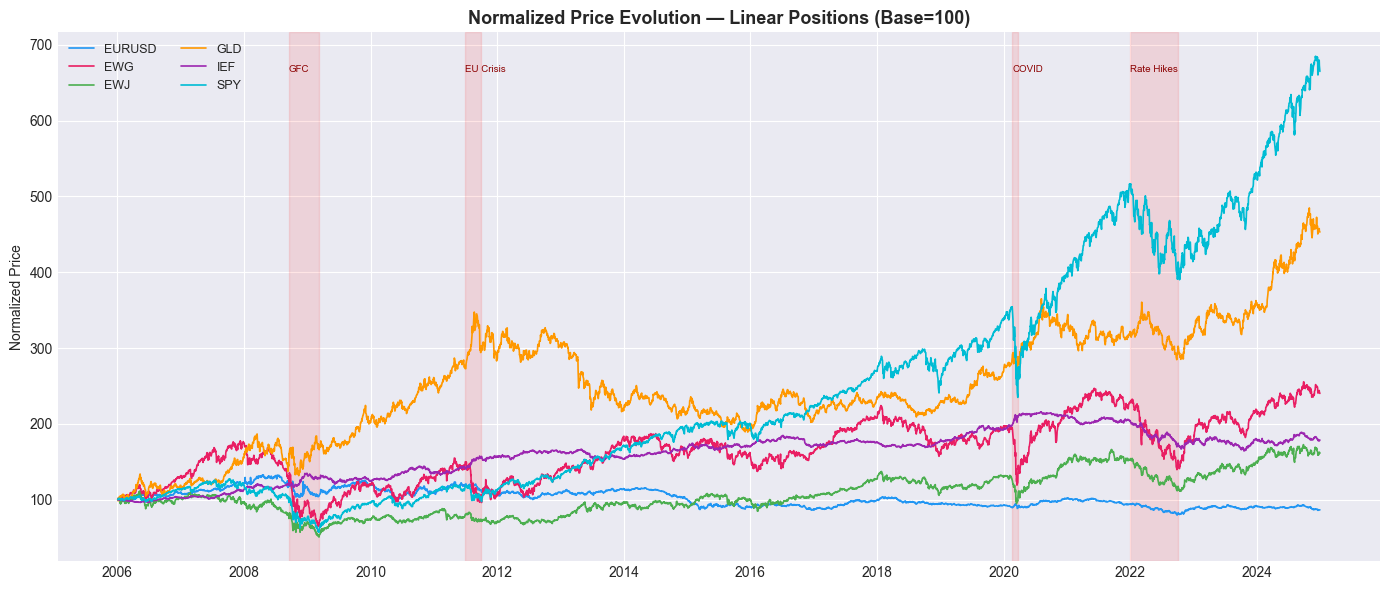

In [12]:
# =============================================================================
# Normalized price evolution (linear positions)
# =============================================================================
prices_norm = (prices / prices.iloc[0]) * 100
 
fig, ax = plt.subplots(figsize=(14, 6))
for i, col in enumerate(prices_norm.columns):
    ax.plot(prices_norm.index, prices_norm[col],
            label=col, color=COLORS[i], linewidth=1.2)
for start, end, label in crises:
    ax.axvspan(start, end, alpha=0.10, color="red")
    ax.text(pd.Timestamp(start), prices_norm.max().max()*0.97,
            label, fontsize=7, color="darkred")
ax.set_title("Normalized Price Evolution — Linear Positions (Base=100)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Normalized Price")
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("outputs/figures/01_normalized_prices.png", dpi=150)
plt.show()

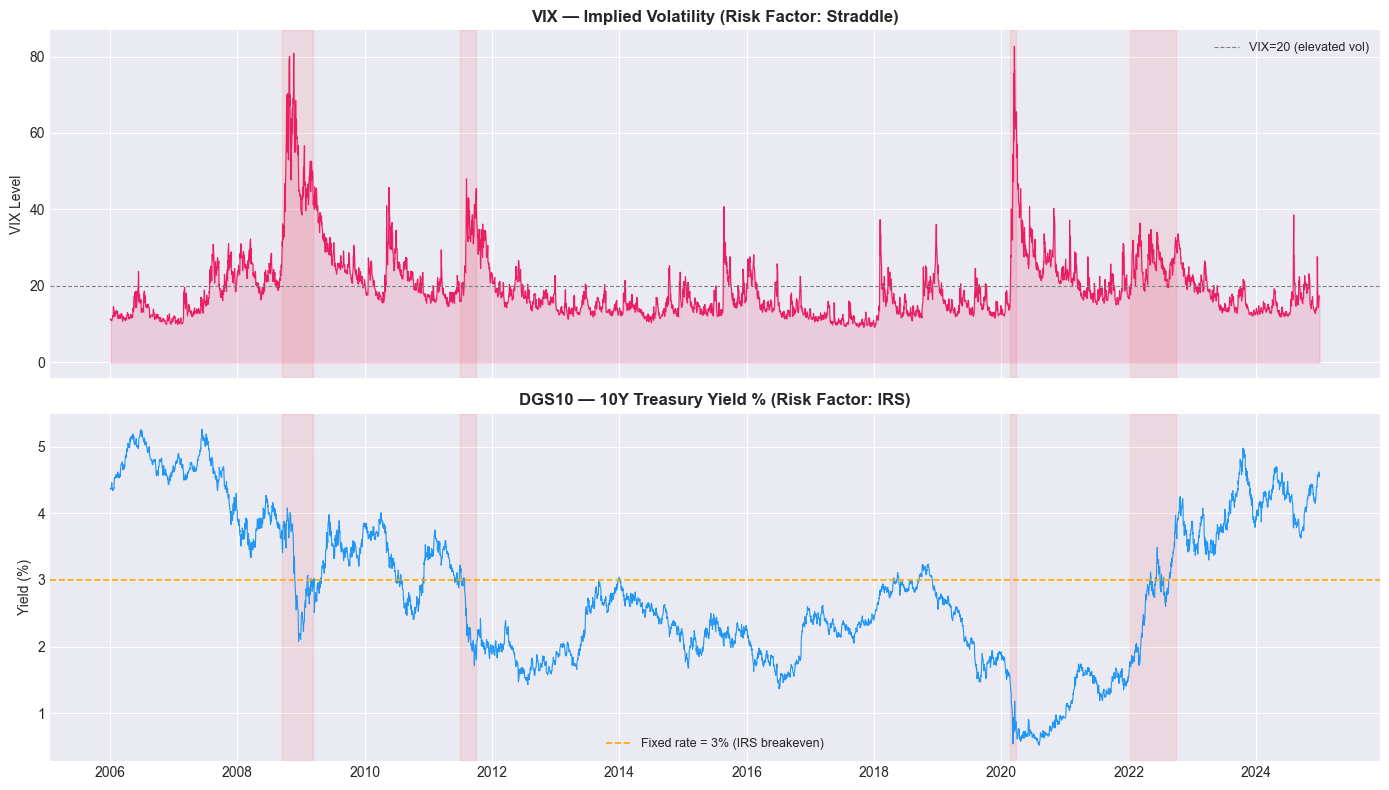

In [13]:
# =============================================================================
# VIX and DGS10 (risk factors for non-linear instruments)
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
 
axes[0].plot(vix.index, vix.values, color="#E91E63", linewidth=0.8)
axes[0].fill_between(vix.index, 0, vix.values, alpha=0.15, color="#E91E63")
axes[0].axhline(20, color="gray", linewidth=0.8, linestyle="--",
                label="VIX=20 (elevated vol)")
axes[0].set_title("VIX — Implied Volatility (Risk Factor: Straddle)",
                   fontsize=12, fontweight="bold")
axes[0].set_ylabel("VIX Level")
axes[0].legend(fontsize=9)
 
axes[1].plot(dgs10.index, dgs10.values, color="#2196F3", linewidth=0.8)
axes[1].axhline(3.0, color="orange", linewidth=1.2, linestyle="--",
                label="Fixed rate = 3% (IRS breakeven)")
axes[1].set_title("DGS10 — 10Y Treasury Yield % (Risk Factor: IRS)",
                   fontsize=12, fontweight="bold")
axes[1].set_ylabel("Yield (%)")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
for ax in axes:
    for start, end, label in crises:
        ax.axvspan(start, end, alpha=0.08, color="red")
 
plt.tight_layout()
plt.savefig("outputs/figures/02_vix_dgs10.png", dpi=150)
plt.show()

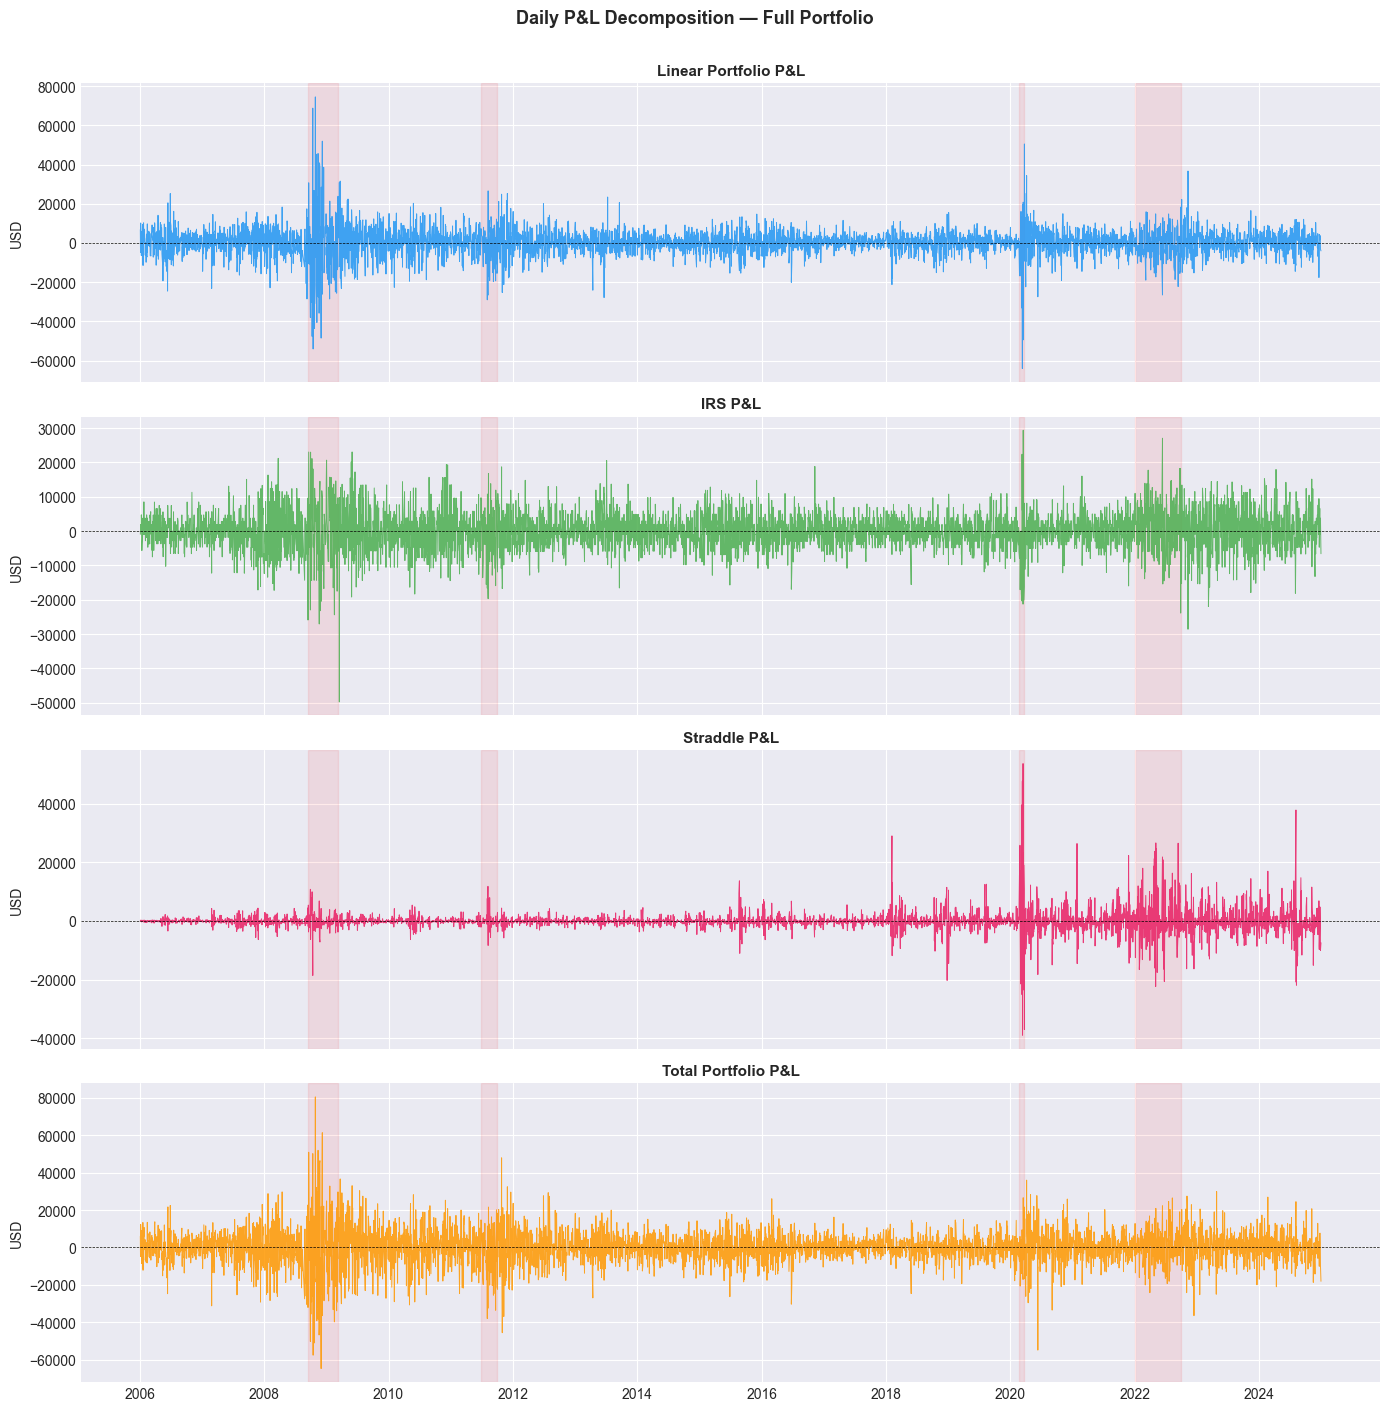

In [ ]:
# =============================================================================
# Daily P&L decomposition
# =============================================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
 
components = [
    ("pnl_linear",   "Linear Portfolio P&L",  "#2196F3"),
    ("pnl_irs",      "IRS P&L",               "#4CAF50"),
    ("pnl_straddle", "Straddle P&L",           "#E91E63"),
    ("pnl_total",    "Total Portfolio P&L",    "#FF9800"),
]
 
for ax, (col, title, color) in zip(axes, components):
    ax.plot(total_pnl.index, total_pnl[col],
            color=color, linewidth=0.7, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("USD")
    for start, end, label in crises:
        ax.axvspan(start, end, alpha=0.08, color="red")
 
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("Daily P&L Decomposition — Full Portfolio",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig("outputs/figures/03_pnl_decomposition.png", dpi=150)
plt.show()

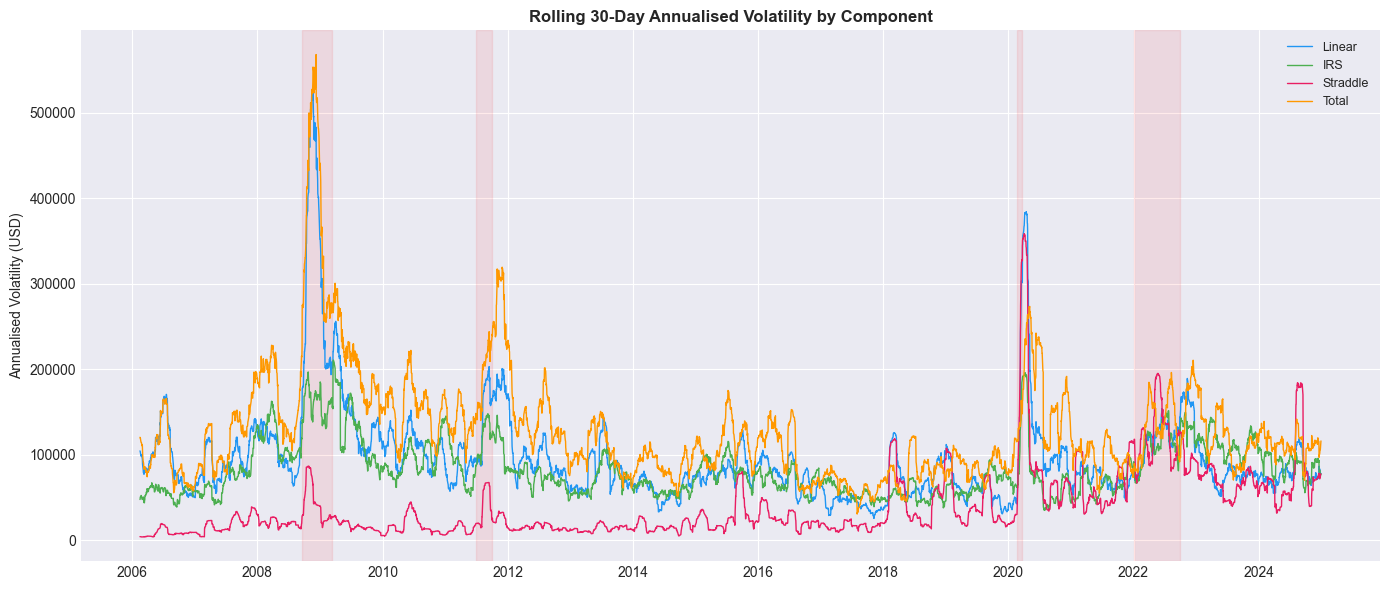

In [15]:
# =============================================================================
# Rolling 30-day volatility by component
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6))
 
for col, label, color in [
    ("pnl_linear",   "Linear",   "#2196F3"),
    ("pnl_irs",      "IRS",      "#4CAF50"),
    ("pnl_straddle", "Straddle", "#E91E63"),
    ("pnl_total",    "Total",    "#FF9800"),
]:
    rolling_vol = total_pnl[col].rolling(30).std() * np.sqrt(252)
    ax.plot(total_pnl.index, rolling_vol, label=label, color=color, linewidth=1.0)
 
ax.set_title("Rolling 30-Day Annualised Volatility by Component",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Annualised Volatility (USD)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for start, end, label in crises:
    ax.axvspan(start, end, alpha=0.08, color="red")
 
plt.tight_layout()
plt.savefig("outputs/figures/04_rolling_vol_components.png", dpi=150)
plt.show()

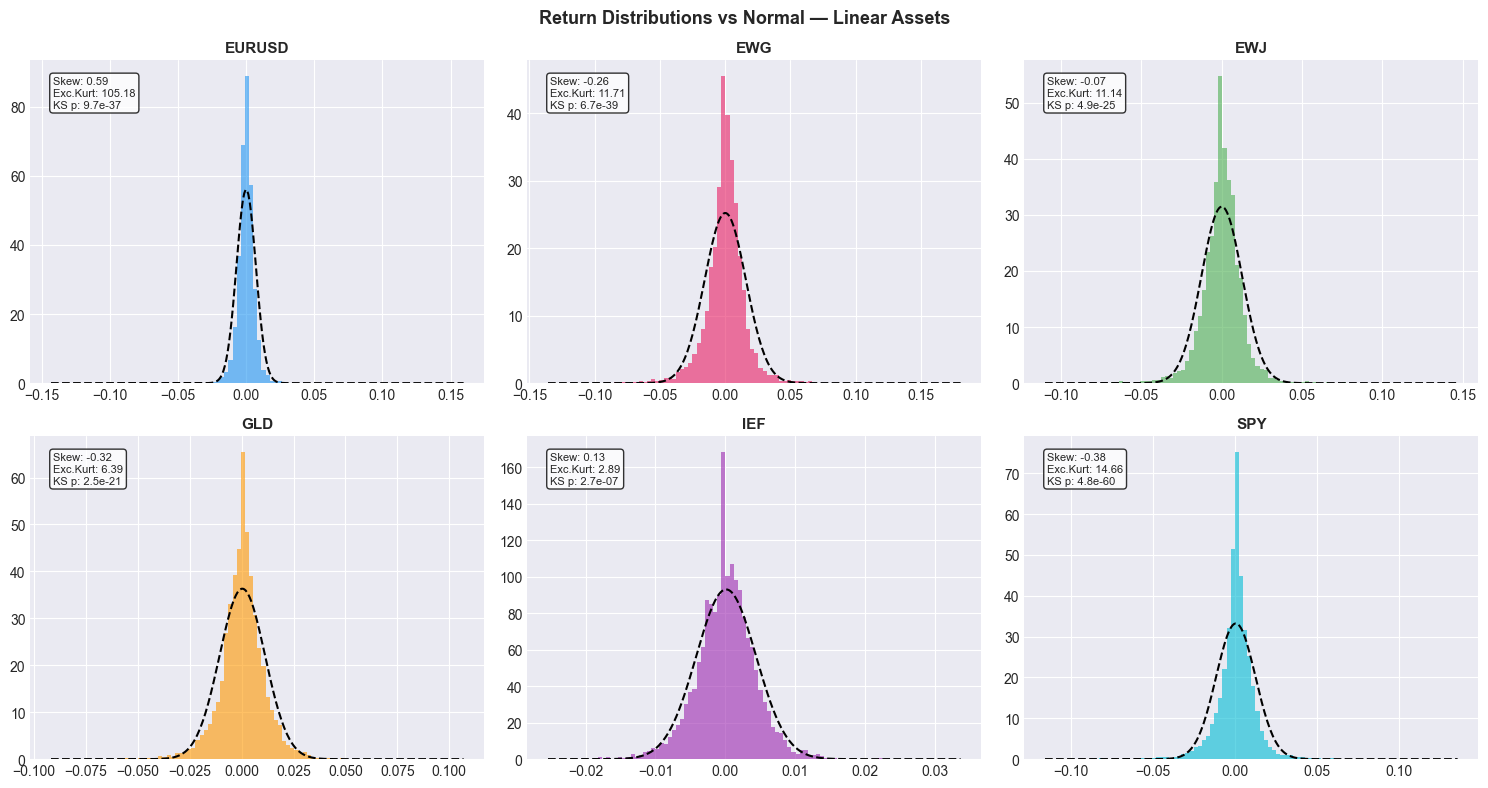

In [16]:
# =============================================================================
# Return distributions for linear assets (KS test)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
 
for i, col in enumerate(returns.columns):
    r = returns[col].dropna()
    mu, sigma = r.mean(), r.std()
    axes[i].hist(r, bins=100, density=True, color=COLORS[i], alpha=0.6)
    x = np.linspace(r.min(), r.max(), 300)
    axes[i].plot(x, stats.norm.pdf(x, mu, sigma), "k--", linewidth=1.5)
    sk = stats.skew(r)
    ku = stats.kurtosis(r)
    ks_stat, ks_p = kstest(r, "norm", args=(mu, sigma))
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].text(0.05, 0.95,
                 f"Skew: {sk:.2f}\nExc.Kurt: {ku:.2f}\nKS p: {ks_p:.1e}",
                 transform=axes[i].transAxes, verticalalignment="top",
                 fontsize=8, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
 
plt.suptitle("Return Distributions vs Normal — Linear Assets",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/05_return_distributions.png", dpi=150)
plt.show()

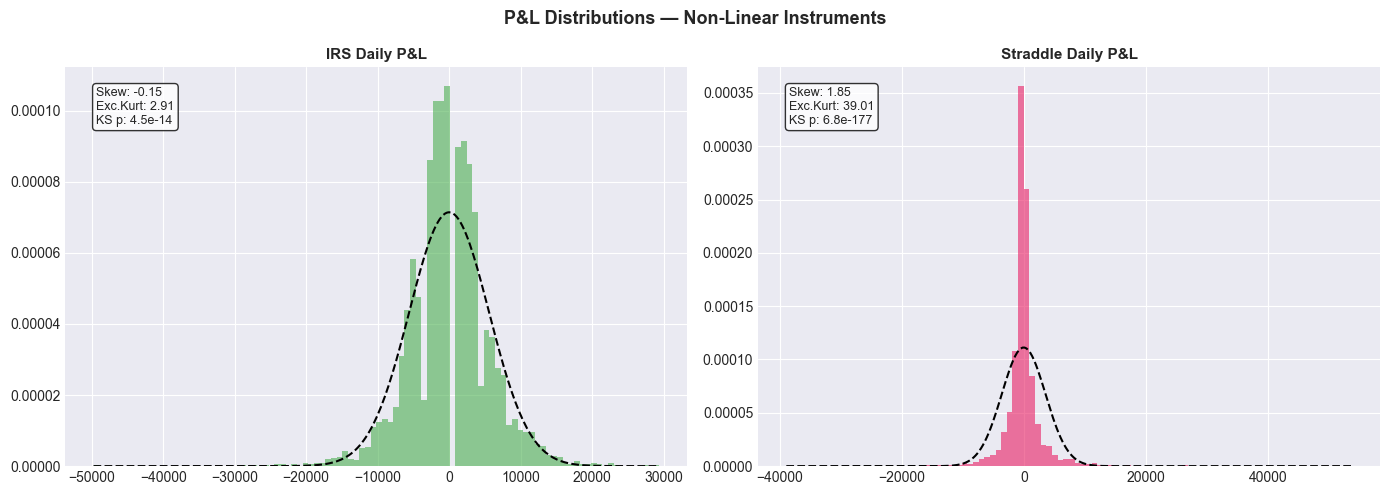

In [18]:
# =============================================================================
# P&L distributions for IRS and straddle
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, col, title, color in [
    (axes[0], "pnl_irs",      "IRS Daily P&L",      "#4CAF50"),
    (axes[1], "pnl_straddle", "Straddle Daily P&L", "#E91E63"),
]:
    r = total_pnl[col].dropna()
    mu, sigma = r.mean(), r.std()
    ax.hist(r, bins=100, density=True, color=color, alpha=0.6)
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "k--", linewidth=1.5)
    sk = stats.skew(r)
    ku = stats.kurtosis(r)
    ks_stat, ks_p = kstest(r, "norm", args=(mu, sigma))
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.text(0.05, 0.95,
            f"Skew: {sk:.2f}\nExc.Kurt: {ku:.2f}\nKS p: {ks_p:.1e}",
            transform=ax.transAxes, verticalalignment="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
 
plt.suptitle("P&L Distributions — Non-Linear Instruments",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/06_instrument_pnl_distributions.png", dpi=150)
plt.show()

In [ ]:
# =============================================================================
# QQ plots for all linear assets
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(returns.columns[:4]):
    r = returns[col].dropna()
    stats.probplot(r, dist="norm", plot=axes[i])
    axes[i].set_title(f"QQ — {col}", fontsize=11, fontweight="bold")
    axes[i].get_lines()[0].set(markersize=1.5, alpha=0.5, color=COLORS[i])
    axes[i].get_lines()[1].set(color="black", linewidth=1.5)

plt.suptitle("QQ Plots: Normality Check — Linear Assets",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/07_qq_plots.png", dpi=150)
plt.show()

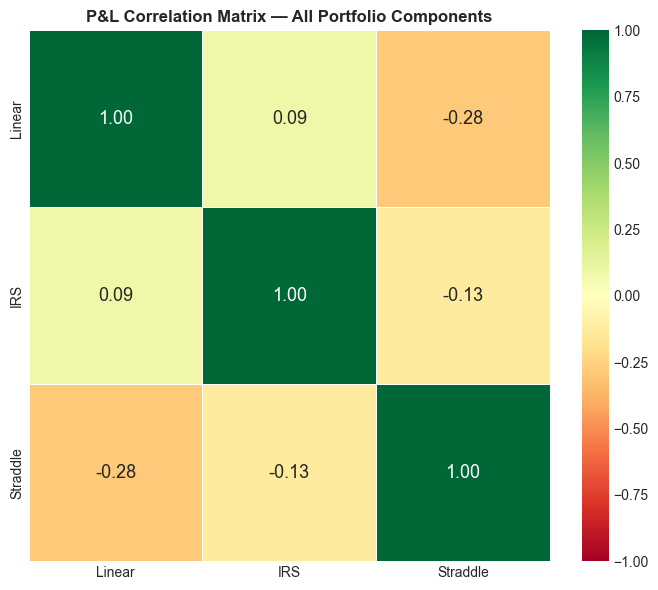

In [21]:
# =============================================================================
# Correlation matrix (all P&L components)
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 6))
 
pnl_corr = total_pnl[["pnl_linear","pnl_irs","pnl_straddle"]].copy()
pnl_corr.columns = ["Linear", "IRS", "Straddle"]
 
sns.heatmap(pnl_corr.corr(), annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={"size": 13})
ax.set_title("P&L Correlation Matrix — All Portfolio Components",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/08_correlation_matrix.png", dpi=150)
plt.show()

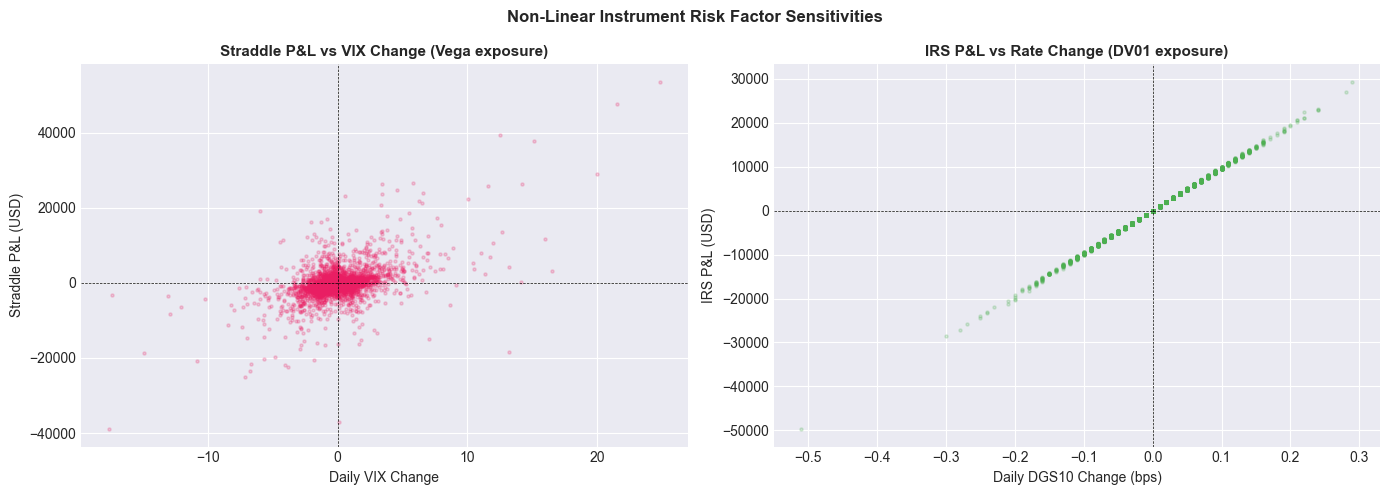

In [22]:
# =============================================================================
# Instrument sensitivities (straddle vs VIX, IRS vs rates)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Straddle P&L vs VIX change
common_v  = total_pnl.index.intersection(vix.index)
vix_chg   = vix.loc[common_v].diff().dropna()
straddle  = total_pnl.loc[vix_chg.index, "pnl_straddle"]
axes[0].scatter(vix_chg, straddle, alpha=0.2, s=5, color="#E91E63")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].axvline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_xlabel("Daily VIX Change")
axes[0].set_ylabel("Straddle P&L (USD)")
axes[0].set_title("Straddle P&L vs VIX Change (Vega exposure)",
                   fontsize=11, fontweight="bold")
 
# IRS P&L vs DGS10 change
common_d = total_pnl.index.intersection(dgs10.index)
dgs_chg  = dgs10.loc[common_d].diff().dropna()
irs_pnl  = total_pnl.loc[dgs_chg.index, "pnl_irs"]
axes[1].scatter(dgs_chg, irs_pnl, alpha=0.2, s=5, color="#4CAF50")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].axvline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("Daily DGS10 Change (bps)")
axes[1].set_ylabel("IRS P&L (USD)")
axes[1].set_title("IRS P&L vs Rate Change (DV01 exposure)",
                   fontsize=11, fontweight="bold")
 
plt.suptitle("Non-Linear Instrument Risk Factor Sensitivities",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/09_instrument_sensitivities.png", dpi=150)
plt.show()

In [23]:
# =============================================================================
# Summary statistics (KS test, Irle p. 167)
# =============================================================================
def summary_stats(df, label=""):
    result = {}
    for col in df.columns:
        r = df[col].dropna()
        ks_stat, ks_p = kstest(r, "norm", args=(r.mean(), r.std()))
        result[col] = {
            "Mean"            : r.mean(),
            "Std"             : r.std(),
            "Min"             : r.min(),
            "Max"             : r.max(),
            "Skewness"        : stats.skew(r),
            "Excess Kurtosis" : stats.kurtosis(r),
            "KS statistic"    : ks_stat,
            "KS p-value"      : ks_p,
            "KS Normal?"      : "NO" if ks_p < 0.05 else "YES"
        }
    out = pd.DataFrame(result).T
    if label:
        print(f"\n{'='*70}\n{label}\n{'='*70}")
        print(out.round(4).to_string())
    return out
 
summary_linear = summary_stats(returns,  "LINEAR ASSET LOG-RETURNS")
summary_instr  = summary_stats(instr_pnl, "INSTRUMENT P&L (IRS + STRADDLE)")
summary_total  = summary_stats(
    total_pnl[["pnl_linear","pnl_irs","pnl_straddle","pnl_total"]],
    "TOTAL PORTFOLIO P&L"
)
 
summary_linear.to_csv("outputs/tables/summary_linear_returns.csv")
summary_instr.to_csv("outputs/tables/summary_instrument_pnl.csv")
summary_total.to_csv("outputs/tables/summary_total_pnl.csv")
print("\nAll summary tables saved.")


LINEAR ASSET LOG-RETURNS
            Mean       Std       Min       Max  Skewness Excess Kurtosis KS statistic KS p-value KS Normal?
EURUSD -0.000029  0.007117 -0.143324  0.159632  0.591735      105.176732     0.091843        0.0         NO
EWG     0.000177  0.015827 -0.135692  0.180567 -0.255634        11.71159     0.094531        0.0         NO
EWJ     0.000097  0.012673 -0.109901  0.146884 -0.070606        11.13515      0.07562        0.0         NO
GLD     0.000306  0.010985 -0.091905  0.106974 -0.320418        6.393271     0.069689        0.0         NO
IEF     0.000117   0.00429 -0.025392  0.033689  0.127548        2.886895     0.039943        0.0         NO
SPY     0.000383  0.012007 -0.115887  0.135577 -0.379876       14.661621     0.117614        0.0         NO

INSTRUMENT P&L (IRS + STRADDLE)
                    Mean          Std           Min           Max  Skewness Excess Kurtosis KS statistic KS p-value KS Normal?
pnl_irs         3.562728  5586.225153 -49741.585221  29354

In [24]:
# =============================================================================
# CELL 12 — Key findings
# =============================================================================
print("""
================================================================================
KEY FINDINGS
================================================================================
1. NORMALITY REJECTED FOR ALL ASSETS (KS test p≈0, Irle p.167):
   Excess kurtosis: EURUSD=105, SPY=14.7, EWG=11.7 — fat tails throughout
   -> Delta-Normal VaR will underestimate risk
   -> Motivates Historical Simulation, GARCH and EVT
 
2. IRS:
   Symmetric P&L around DGS10=3% (fixed rate breakeven)
   Large losses in 2008/2020 (rate cuts), large gains in 2022 (rate hikes)
   Linear in rate changes -> Delta-Normal approximation is adequate
 
3. STRADDLE:
   Negative theta: mean daily P&L = -$105 (time decay)
   Positive skew: profits when VIX spikes (COVID: +$53k max gain)
   Non-linear -> Delta-Normal FAILS, need Delta-Gamma-Vega-Theta (Irle p.82)
 
4. DIVERSIFICATION:
   Total std ($9,034) < sum of components ($16,231)
   Low correlation between IRS/straddle and linear positions
 
5. VOLATILITY CLUSTERING:
   Visible in all components -> motivates GARCH (Irle Section 8)
================================================================================
""")


KEY FINDINGS
1. NORMALITY REJECTED FOR ALL ASSETS (KS test p≈0, Irle p.167):
   Excess kurtosis: EURUSD=105, SPY=14.7, EWG=11.7 — fat tails throughout
   -> Delta-Normal VaR will underestimate risk
   -> Motivates Historical Simulation, GARCH and EVT

2. IRS:
   Symmetric P&L around DGS10=3% (fixed rate breakeven)
   Large losses in 2008/2020 (rate cuts), large gains in 2022 (rate hikes)
   Linear in rate changes -> Delta-Normal approximation is adequate

3. STRADDLE:
   Negative theta: mean daily P&L = -$105 (time decay)
   Positive skew: profits when VIX spikes (COVID: +$53k max gain)
   Non-linear -> Delta-Normal FAILS, need Delta-Gamma-Vega-Theta (Irle p.82)

4. DIVERSIFICATION:
   Total std ($9,034) < sum of components ($16,231)
   Low correlation between IRS/straddle and linear positions

5. VOLATILITY CLUSTERING:
   Visible in all components -> motivates GARCH (Irle Section 8)



In [ ]:
# =============================================================================
# Pre-GARCH tests: autocorrelation and ARCH effects
# Theory: report/theoretical_background.md — Section 12.2, 12.3
#
# These tests on RAW RETURNS motivate why GARCH is needed:
#   - Ljung-Box on returns         → autocorrelation in mean (justifies ARMA)
#   - Ljung-Box on squared returns → volatility clustering (justifies GARCH)
#   - Engle's ARCH test            → conditional heteroskedasticity
#
# Reference: Irle p. 166-167
# =============================================================================
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
import statsmodels.api as sm

LAGS = 10   # number of lags to test (standard choice)
ALPHA_TEST = 0.05

results = {}

for col in returns.columns:
    r  = returns[col].dropna()
    r2 = r ** 2

    # --- Ljung-Box on returns (Property 1: autocorrelation in mean) ---
    lb_r  = acorr_ljungbox(r,  lags=LAGS, return_df=True)
    # --- Ljung-Box on squared returns (Property 2: volatility clustering) ---
    lb_r2 = acorr_ljungbox(r2, lags=LAGS, return_df=True)
    # --- Engle's ARCH test (Property 2 alternative) ---
    arch_stat, arch_p, _, _ = het_arch(r, nlags=LAGS)

    # Use p-value at lag 10 as summary
    results[col] = {
        "LB(10) returns — stat"    : lb_r["lb_stat"].iloc[-1],
        "LB(10) returns — p"       : lb_r["lb_pvalue"].iloc[-1],
        "LB(10) returns — H0 rej?" : "YES" if lb_r["lb_pvalue"].iloc[-1] < ALPHA_TEST else "NO",
        "LB(10) squared — stat"    : lb_r2["lb_stat"].iloc[-1],
        "LB(10) squared — p"       : lb_r2["lb_pvalue"].iloc[-1],
        "LB(10) squared — H0 rej?": "YES" if lb_r2["lb_pvalue"].iloc[-1] < ALPHA_TEST else "NO",
        "ARCH(10) — stat"          : arch_stat,
        "ARCH(10) — p"             : arch_p,
        "ARCH(10) — H0 rej?"       : "YES" if arch_p < ALPHA_TEST else "NO",
    }

results_df = pd.DataFrame(results).T

print(f"\n{'='*70}")
print(f"PRE-GARCH TESTS (Irle p. 166-167)")
print(f"{'='*70}")
print(f"H0 for Ljung-Box  : first {LAGS} autocorrelations are jointly zero")
print(f"H0 for ARCH test  : no ARCH effects (homoskedastic residuals)")
print(f"Rejection level   : alpha = {ALPHA_TEST}")
print(f"\n--- Ljung-Box on RETURNS (autocorrelation in mean) ---")
lb_cols = ["LB(10) returns — stat", "LB(10) returns — p", "LB(10) returns — H0 rej?"]
print(results_df[lb_cols].round(4).to_string())

print(f"\n--- Ljung-Box on SQUARED RETURNS (volatility clustering) ---")
lb2_cols = ["LB(10) squared — stat", "LB(10) squared — p", "LB(10) squared — H0 rej?"]
print(results_df[lb2_cols].round(4).to_string())

print(f"\n--- Engle's ARCH test (conditional heteroskedasticity) ---")
arch_cols = ["ARCH(10) — stat", "ARCH(10) — p", "ARCH(10) — H0 rej?"]
print(results_df[arch_cols].round(4).to_string())

# Save
results_df.to_csv("outputs/tables/pre_garch_tests.csv")
print(f"\nSaved -> outputs/tables/pre_garch_tests.csv")


PRE-GARCH TESTS (Irle p. 166-167)
H0 for Ljung-Box  : first 10 autocorrelations are jointly zero
H0 for ARCH test  : no ARCH effects (homoskedastic residuals)
Rejection level   : alpha = 0.05

--- Ljung-Box on RETURNS (autocorrelation in mean) ---
       LB(10) returns — stat LB(10) returns — p LB(10) returns — H0 rej?
EURUSD            219.144471                0.0                      YES
EWG                31.033183           0.000579                      YES
EWJ                65.944474                0.0                      YES
GLD                16.562089           0.084633                       NO
IEF                 36.52349           0.000068                      YES
SPY                80.123124                0.0                      YES

--- Ljung-Box on SQUARED RETURNS (volatility clustering) ---
       LB(10) squared — stat LB(10) squared — p LB(10) squared — H0 rej?
EURUSD           1182.538404                0.0                      YES
EWG              2486.911147    

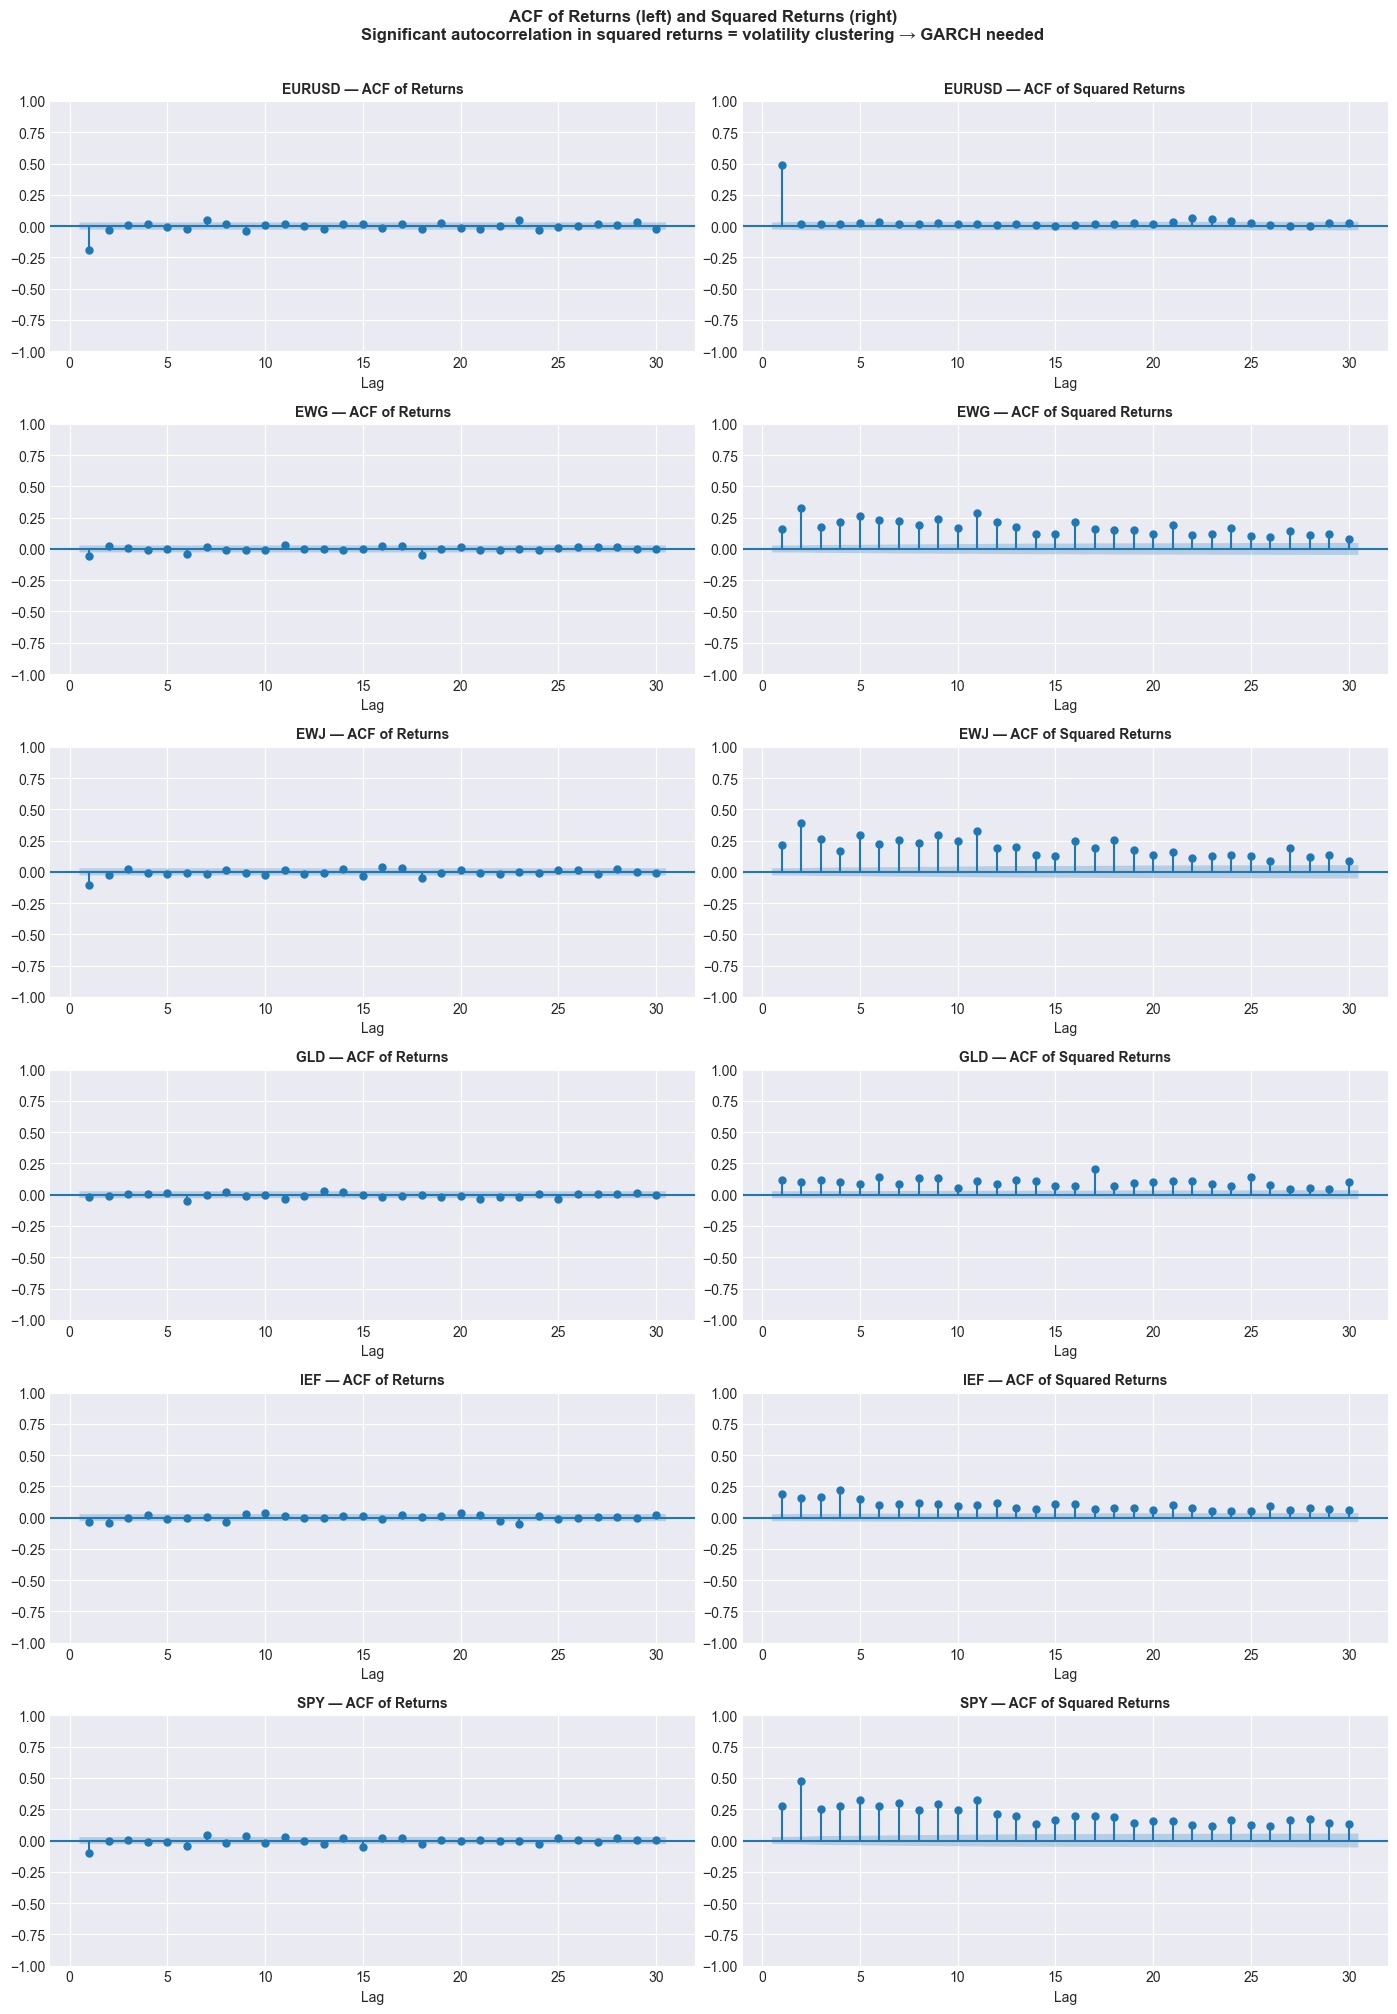

In [26]:
# =============================================================================
# ACF plots: returns and squared returns
# Visual confirmation of Ljung-Box results (Irle p. 166)
# =============================================================================
fig, axes = plt.subplots(6, 2, figsize=(14, 20))

for i, col in enumerate(returns.columns):
    r  = returns[col].dropna()
    r2 = r ** 2

    # ACF of returns
    sm.graphics.tsa.plot_acf(r,  lags=30, ax=axes[i][0],
                              alpha=0.05, zero=False)
    axes[i][0].set_title(f"{col} — ACF of Returns",
                          fontsize=10, fontweight="bold")
    axes[i][0].set_xlabel("Lag")

    # ACF of squared returns
    sm.graphics.tsa.plot_acf(r2, lags=30, ax=axes[i][1],
                              alpha=0.05, zero=False)
    axes[i][1].set_title(f"{col} — ACF of Squared Returns",
                          fontsize=10, fontweight="bold")
    axes[i][1].set_xlabel("Lag")

plt.suptitle(
    "ACF of Returns (left) and Squared Returns (right)\n"
    "Significant autocorrelation in squared returns = volatility clustering → GARCH needed",
    fontsize=12, fontweight="bold", y=1.005
)
plt.tight_layout()
plt.savefig("outputs/figures/10_acf_plots.png", dpi=150)
plt.show()